In [83]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

In [84]:
df = pd.read_csv("StoreSalesForecasting.csv",encoding='windows-1252')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
2117,9965,CA-2016-146374,12/5/2016,12/10/2016,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320
2118,9981,US-2015-151435,9/6/2015,9/9/2015,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,...,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548
2119,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [86]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [87]:
df.shape

(2121, 21)

In [88]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [89]:
df.duplicated().sum()

np.int64(0)

In [90]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [91]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    1248
Second Class       427
First Class        327
Same Day           119
Name: count, dtype: int64

In [92]:
df['Segment'].value_counts()

Segment
Consumer       1113
Corporate       646
Home Office     362
Name: count, dtype: int64

In [93]:
print(df['Country'].value_counts())
print(df['City'].value_counts())

Country
United States    2121
Name: count, dtype: int64
City
New York City     192
Los Angeles       154
Philadelphia      111
San Francisco     102
Seattle            97
                 ... 
Mansfield           1
Hillsboro           1
Bryan               1
San Bernardino      1
Indianapolis        1
Name: count, Length: 371, dtype: int64


In [94]:
print(df['Region'].value_counts())

Region
West       707
East       601
Central    481
South      332
Name: count, dtype: int64


**DROPPING UNWANTED COLUMNS**

In [95]:
df = df.drop(columns=['Row ID' , 'Order ID' ,'Customer ID', 'Customer Name', 'Product ID','Product Name','Postal Code' , 'Ship Date'])

In [96]:
df

,Order Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,11/8/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,11/8/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,10/11/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
3,6/9/2014,Standard Class,Consumer,United States,Los Angeles,California,West,Furniture,Furnishings,48.8600,7,0.00,14.1694
4,6/9/2014,Standard Class,Consumer,United States,Los Angeles,California,West,Furniture,Tables,1706.1840,9,0.20,85.3092
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,3/19/2015,First Class,Home Office,United States,Houston,Texas,Central,Furniture,Bookcases,383.4656,4,0.32,-67.6704
2117,12/5/2016,Second Class,Corporate,United States,Newark,Delaware,East,Furniture,Furnishings,13.4000,1,0.00,6.4320
2118,9/6/2015,Second Class,Consumer,United States,Lafayette,Louisiana,South,Furniture,Tables,85.9800,1,0.00,22.3548
2119,1/21/2014,Second Class,Consumer,United States,Miami,Florida,South,Furniture,Furnishings,25.2480,3,0.20,4.1028


In [97]:
df.dtypes

Order Date       object
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

**FIXING ORDER DATE COLUMN DATA TYPE TO DATETIME**

In [98]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [99]:
df['Order Date'].dtype

dtype('<M8[ns]')

In [100]:
print(df['Order Date'].max())   #start
print(df['Order Date'].min())   #end 

#It is range of data means the data is of 4 years 2014-2017

#4 years data is enough for prophet 

2017-12-30 00:00:00
2014-01-06 00:00:00


In [101]:
#categorical columns :- 
categorical_columns = df.select_dtypes(include="object").columns 

In [102]:
categorical_columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region',
       'Category', 'Sub-Category'],
      dtype='object')

In [103]:
df = df.drop(columns=['Country','City','State'])

In [76]:
df.head(2)

,Order Date,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,Second Class,Consumer,South,Furniture,Bookcases,261.96,2,0.0,41.9136
1,2016-11-08,Second Class,Consumer,South,Furniture,Chairs,731.94,3,0.0,219.5820


In [105]:
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns

Index(['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category'], dtype='object')

**LABEL ENCODING**

In [106]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_column = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category'] 
for col in cat_column: 
    df[col] = le.fit_transform(df[col])
    

In [107]:
df.head()

,Order Date,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,2,0,2,0,0,261.9600,2,0.00,41.9136
1,2016-11-08,2,0,2,0,1,731.9400,3,0.00,219.5820
2,2015-10-11,3,0,2,0,3,957.5775,5,0.45,-383.0310
3,2014-06-09,3,0,3,0,2,48.8600,7,0.00,14.1694
4,2014-06-09,3,0,3,0,3,1706.1840,9,0.20,85.3092


In [108]:
df.dtypes

Order Date      datetime64[ns]
Ship Mode                int64
Segment                  int64
Region                   int64
Category                 int64
Sub-Category             int64
Sales                  float64
Quantity                 int64
Discount               float64
Profit                 float64
dtype: object

In [110]:
df.to_csv("Cleaned_SalesStoreForecasting.csv" , index = False)

**EDA**

In [116]:
df.describe(include=(int,float))

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.0,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,2.223951,0.645922,1.596417,0.0,1.644507,349.834887,3.785007,0.173923,8.699327
std,1.100734,0.755198,1.166864,0.0,0.863286,503.179145,2.251620,0.181547,136.049246
min,0.000000,0.000000,0.000000,0.0,0.000000,1.892000,1.000000,0.000000,-1862.312400
25%,2.000000,0.000000,1.000000,0.0,1.000000,47.040000,2.000000,0.000000,-12.849000
50%,3.000000,0.000000,1.000000,0.0,2.000000,182.220000,3.000000,0.200000,7.774800
75%,3.000000,1.000000,3.000000,0.0,2.000000,435.168000,5.000000,0.300000,33.726600
max,3.000000,2.000000,3.000000,0.0,3.000000,4416.174000,14.000000,0.700000,1013.127000


In [117]:
df['Category'].value_counts()

Category
0    2121
Name: count, dtype: int64

In [118]:
df['Sub-Category'].value_counts()

Sub-Category
2    957
1    617
3    319
0    228
Name: count, dtype: int64

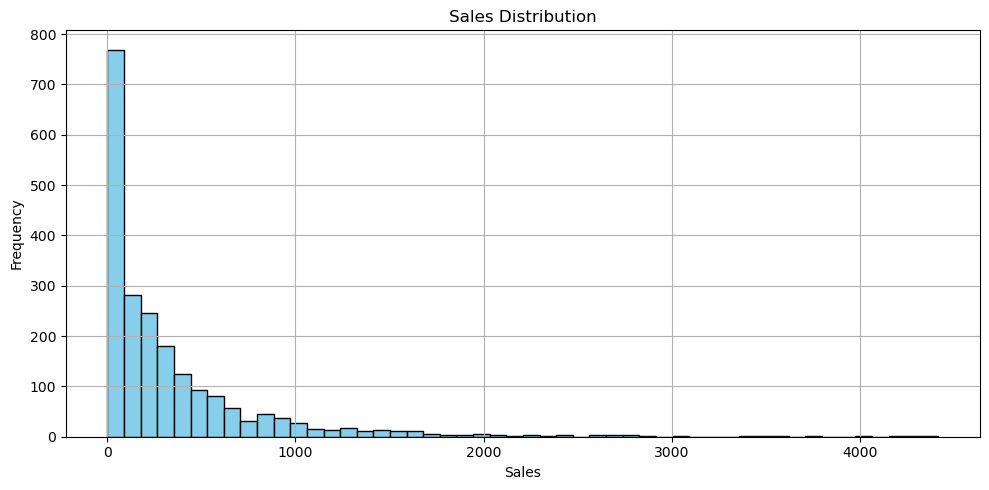

Skewness: 3.3491680662644945


In [136]:
#Sales distribution:-
plt.figure(figsize=(10,5))
df['Sales'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Skewness:", df['Sales'].skew())

In [137]:
# vey much skewed 
#log transformation 
df['Sales_log'] = np.log1p(df['Sales'])
#original vs log skewness value 
print(df['Sales'].skew())
print(df['Sales_log'].skew())

3.3491680662644945
-0.2715180262206051


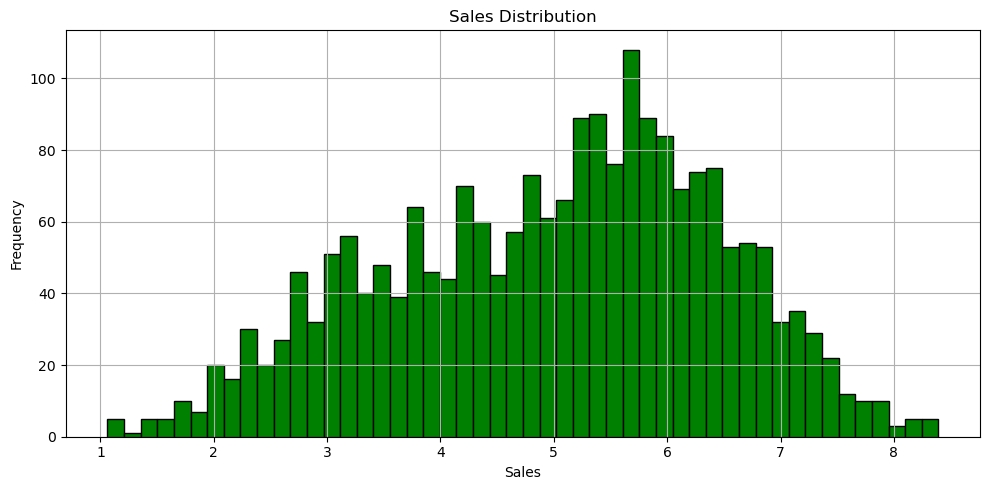

In [138]:
plt.figure(figsize=(10,5))
df['Sales_log'].hist(bins=50, color='green', edgecolor='black')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

MONTHLY SALES TREND :-

In [139]:
df['Month'] = df['Order Date'].dt.to_period("M")

In [140]:
monthly_Sales = df.groupby("Month")['Sales'].sum()

In [141]:
monthly_Sales

Month
2014-01     6242.5250
2014-02     1839.6580
2014-03    14573.9560
2014-04     7944.8370
2014-05     6912.7870
2014-06    13206.1256
2014-07    10821.0510
2014-08     7320.3465
2014-09    23816.4808
2014-10    12304.2470
2014-11    21564.8727
2014-12    30645.9665
2015-01    11739.9416
2015-02     3134.3740
2015-03    12499.7830
2015-04    10475.6985
2015-05     9374.9505
2015-06     7714.1790
2015-07    13674.4200
2015-08     9638.5922
2015-09    26273.0230
2015-10    12026.6235
2015-11    30880.8325
2015-12    23085.8192
2016-01     7622.7430
2016-02     3925.5510
2016-03    12801.0920
2016-04    13212.0900
2016-05    15119.8350
2016-06    13070.5720
2016-07    13068.5190
2016-08    12483.2323
2016-09    27262.8809
2016-10    11872.5770
2016-11    31783.6288
2016-12    36678.7150
2017-01     5964.0320
2017-02     6866.3374
2017-03    10893.4448
2017-04     9065.9581
2017-05    16957.5582
2017-06    19008.5867
2017-07    11813.0220
2017-08    15441.8740
2017-09    29028.2060
2017

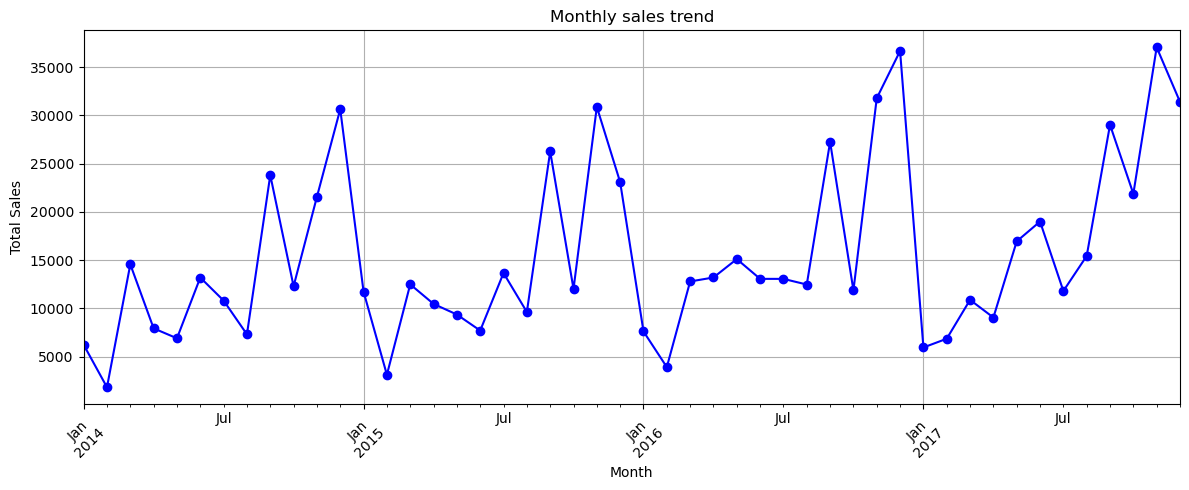

In [142]:
plt.figure(figsize=(12,5))
monthly_Sales.plot(kind='line' , marker = 'o' , color = 'blue')
plt.title("Monthly sales trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation = 45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Sales by region**

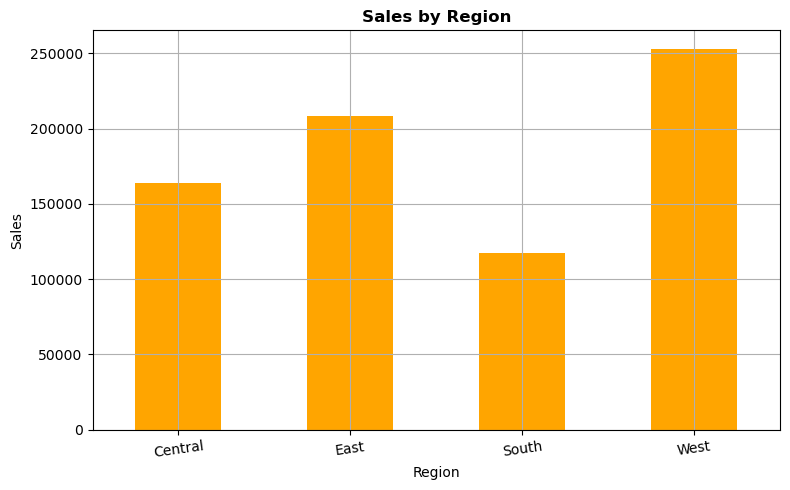

In [148]:
region_map = {0:'Central',1:'East',2:'South',3:'West'}
df['region_name'] = df['Region'].map(region_map)
plt.figure(figsize=(8,5))
df.groupby('region_name')['Sales'].sum().plot(kind = 'bar' , color='orange')
plt.title("Sales by Region" , fontsize = 12 , fontweight='bold')
plt.xlabel('Region')
plt.ylabel("Sales")
plt.xticks(rotation = 8)
plt.tight_layout()
plt.grid(True)
plt.show()

**YEARLY SALES GROWTH**

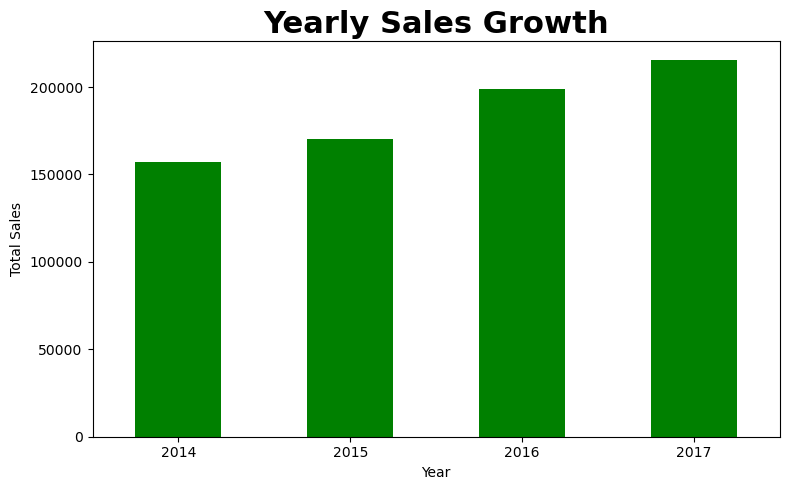

In [152]:
df['year'] = df['Order Date'].dt.year
plt.figure(figsize=(8,5))
df.groupby("year")["Sales"].sum().plot(kind = 'bar' , color='green')
plt.title("Yearly Sales Growth", fontsize = 22 , fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

**PROPHET MODEL**

In [175]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
# daily_sales 
daily_sales.columns = ['ds' , 'y']  #renaming in prophet formate
print(daily_sales.shape)
print(daily_sales.min())  #start 
print(daily_sales.max())  #end

daily_sales.head()

(889, 2)
ds    2014-01-06 00:00:00
y                   1.988
dtype: object
ds    2017-12-30 00:00:00
y               10006.174
dtype: object


,ds,y
0,2014-01-06,2573.820
1,2014-01-07,76.728
2,2014-01-10,51.940
3,2014-01-11,9.940
4,2014-01-13,879.939


In [159]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ------ --------------------------------- 1.8/12.1 MB 14.8 MB/s eta 0:00:01
   ---------------- ----------------------- 5.0/12.1 MB 14.1 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.1 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 15.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 16.8 MB/s eta 0:00:00

   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays

In [160]:
from prophet import Prophet

In [162]:
model = Prophet(yearly_seasonality=True , weekly_seasonality= True , daily_seasonality=False)
model.fit(daily_sales)

14:23:48 - cmdstanpy - INFO - Chain [1] start processing
14:23:50 - cmdstanpy - INFO - Chain [1] done processing


**30 days future prediction**

In [167]:
#future of 30 days 
future = model.make_future_dataframe(periods=30)
#prediction  
forecast = model.predict(future)
# forecast.shape 
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(10)

# yhat = Predicted Sales
# yhat_lower = Minimum expected
# yhat_upper = Maximum expected

,ds,yhat,yhat_lower,yhat_upper
909,2018-01-20,320.708654,-907.563390,1476.700918
910,2018-01-21,470.330884,-781.456567,1655.936619
911,2018-01-22,665.583841,-487.993574,1972.575216
912,2018-01-23,292.052831,-857.070959,1510.464854
913,2018-01-24,269.814155,-984.279546,1539.541028
914,2018-01-25,497.323287,-819.247203,1657.485351
915,2018-01-26,544.599080,-730.287504,1899.817435
916,2018-01-27,347.654334,-969.149858,1538.456541
917,2018-01-28,511.227654,-675.315102,1846.604081
918,2018-01-29,719.060002,-576.589937,1901.143350


In [165]:
forecast.shape

# 919 rows = 889 original + 30 future days 
# 19 columns = Prophet's internal calculations

(919, 19)

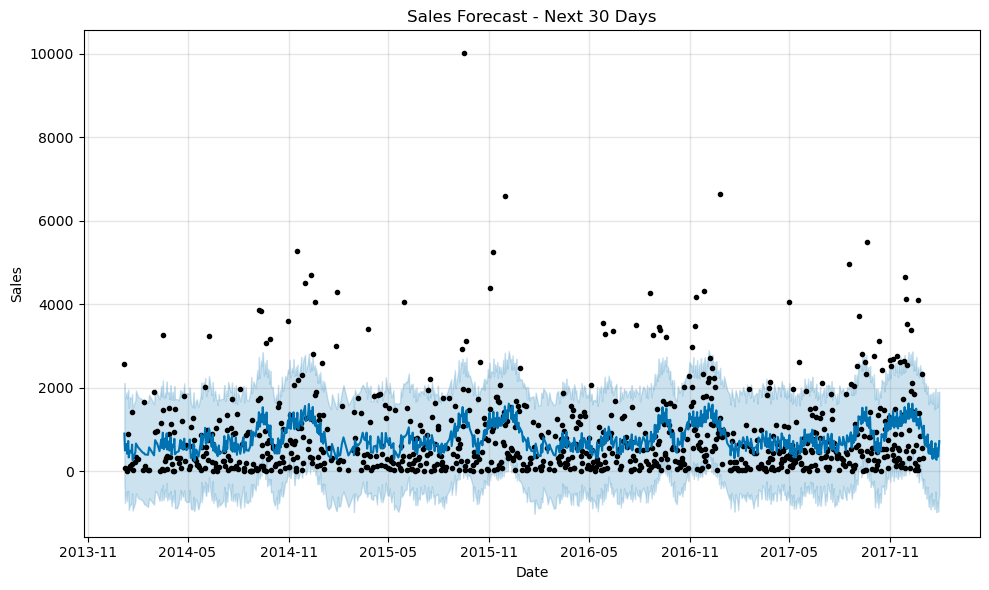

In [168]:
fig = model.plot(forecast)
plt.title('Sales Forecast - Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

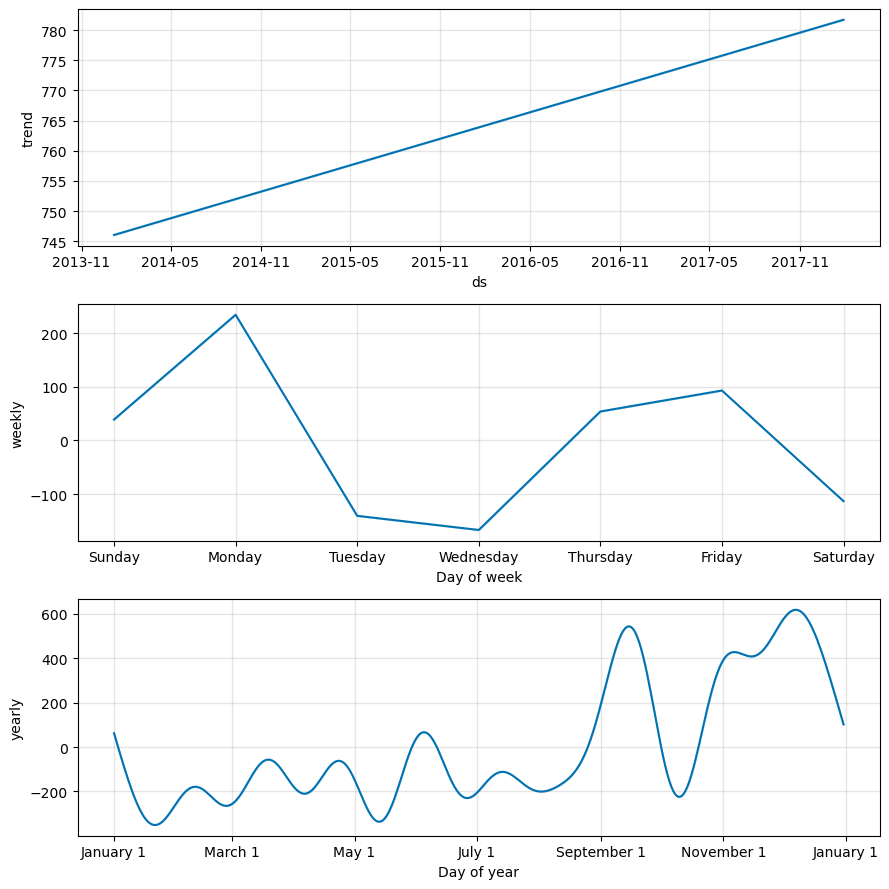

In [169]:
fig = model.plot_components(forecast)
plt.tight_layout()
plt.show()

**MAPE**

In [171]:
from sklearn.metrics import mean_absolute_percentage_error

actual = daily_sales['y'].values
predicted = forecast['yhat'][:len(daily_sales)].values

mape = mean_absolute_percentage_error(actual, predicted)
mape

7.413752667879912

In [172]:
# Weekly Seasonality (Monday peak)
# Yearly Seasonality (Nov-Dec peak)

In [182]:
# all negative sales yhat_lower(Minimum expected) is changed to 0 beacuse sales coming negative


# Prophet is predicting negative sales values because our dataset 
# has gaps - not every day has an order (889 days out of 1460 total days).
# Prophet tries to fill these missing days and sometimes predicts 
# negative values due to uncertainty in sparse data.
# Solution:- I cliped negative predictions to 0 beacuse
# minimum possible sales cannot be negative. 




forecast['yhat'] = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)

In [183]:
# Future predictions 
# future_forecast = forecast[forecast['ds'] > '2017-12-30']
#save 
# future_forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv('Future_sales_forecast.csv', index=False)